# 🛒 Intelligent Ordering System — ML Model Evaluation
### Predicting Customer Product Preferences using SVM, Random Forest & XGBoost

---

## 📋 Project Overview

This notebook implements the **Intelligent Ordering System** component of the platform, which analyses purchase history and predicts frequently ordered items to provide quick re-order options for customers.

We evaluate **three machine learning models** on a real orders dataset:

| Model | Type | Key Strength |
|---|---|---|
| **SVM** | Support Vector Machine | Works well in high-dimensional spaces |
| **Random Forest** | Ensemble (Bagging) | Robust, handles non-linearity, interpretable |
| **XGBoost** | Ensemble (Boosting) | High accuracy, handles imbalanced data |

### 🎯 Task
**Predict which product a user is most likely to order next**, based on their purchase history, order patterns, and product features.

---

## 📁 Dataset
The dataset (`orders_dataset.csv`) contains **~3,000 order line items** from a Bristol-based local food platform with the following columns:

- `order_id`, `user_id`, `username` — identifiers
- `order_date`, `delivery_date`, `order_status` — order logistics
- `product_name`, `category`, `section` — product info
- `quantity`, `unit`, `price_per_unit`, `line_total` — transaction details
- `is_organic`, `producer_name`, `city`, `postcode` — product & location metadata

---
## ⚙️ Section 1 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
# Uncomment if running for the first time
#  !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#1A1D2E',
    'axes.edgecolor':   '#333',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#333',
    'grid.alpha':       0.4,
})

PALETTE = {'SVM': '#6C63FF', 'Random Forest': '#00C9A7', 'XGBoost': '#FF6B6B'}

print('Libraries loaded successfully.')

✅ Libraries loaded successfully.


---
## Section 2 — Load & Explore the Dataset

In [3]:
# ── Load data ──────────────────────────────────────────────────────────────────
# Update the path if your CSV is in a different location
df = pd.read_csv('orders_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Orders: {df["order_id"].nunique()} | Users: {df["user_id"].nunique()} | Products: {df["product_name"].nunique()}')
df.head(10)

Shape: (3026, 18)
Orders: 1000 | Users: 80 | Products: 26


,order_id,user_id,username,order_date,delivery_date,order_status,item_id,product_name,category,section,quantity,unit,price_per_unit,line_total,is_organic,producer_name,city,postcode
0,1,8,eve.taylor8,2025-02-16,2025-02-22,fulfilled,1,Cheese,dairy,all,2,each,4.46,8.92,False,Green Valley Farm,Bristol,BS2 8QD
1,1,8,eve.taylor8,2025-02-16,2025-02-22,fulfilled,2,Broccoli,vegetables,all,1,each,1.89,1.89,True,Green Valley Farm,Bristol,BS2 8QD
2,2,71,karen.jones71,2024-04-10,2024-04-11,fulfilled,3,Rhubarb,fruits,seasonal,2,each,2.08,4.16,False,Avon Growers,Bristol,BS9 1JB
3,3,62,sam.walker62,2024-08-06,2024-08-13,fulfilled,4,Gooseberries,fruits,seasonal,3,each,2.92,8.76,False,Cotswold Fresh,Bristol,BS1 4PJ
4,3,62,sam.walker62,2024-08-06,2024-08-13,fulfilled,5,Apples,fruits,seasonal,4,kg,1.84,7.36,True,Cotswold Fresh,Bristol,BS1 4PJ
5,3,62,sam.walker62,2024-08-06,2024-08-13,fulfilled,6,Wholemeal Bread,bakery,all,6,each,2.86,17.16,False,Cotswold Fresh,Bristol,BS1 4PJ
6,3,62,sam.walker62,2024-08-06,2024-08-13,fulfilled,7,Plums,fruits,seasonal,2,each,2.62,5.24,True,Cotswold Fresh,Bristol,BS1 4PJ
7,4,75,rachel.walker75,2025-07-09,2025-07-10,fulfilled,8,Honey,preserves,all,2,each,4.78,9.56,True,Avon Growers,Bristol,BS1 4PJ
8,4,75,rachel.walker75,2025-07-09,2025-07-10,fulfilled,9,Strawberry Jam,preserves,all,1,each,3.23,3.23,False,Avon Growers,Bristol,BS1 4PJ
9,4,75,rachel.walker75,2025-07-09,2025-07-10,fulfilled,10,Red Onions,vegetables,all,4,kg,1.06,4.24,False,Avon Growers,Bristol,BS1 4PJ


In [4]:
# ── Basic info ─────────────────────────────────────────────────────────────────
print('Column types & nulls:')
df.info()

Column types & nulls:
<class 'pandas.DataFrame'>
RangeIndex: 3026 entries, 0 to 3025
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        3026 non-null   int64  
 1   user_id         3026 non-null   int64  
 2   username        3026 non-null   str    
 3   order_date      3026 non-null   str    
 4   delivery_date   3026 non-null   str    
 5   order_status    3026 non-null   str    
 6   item_id         3026 non-null   int64  
 7   product_name    3026 non-null   str    
 8   category        3026 non-null   str    
 9   section         3026 non-null   str    
 10  quantity        3026 non-null   int64  
 11  unit            3026 non-null   str    
 12  price_per_unit  3026 non-null   float64
 13  line_total      3026 non-null   float64
 14  is_organic      3026 non-null   bool   
 15  producer_name   3026 non-null   str    
 16  city            3026 non-null   str    
 17  postcode        3026 n

In [5]:
# ── Summary statistics ─────────────────────────────────────────────────────────
df.describe()

,order_id,user_id,item_id,quantity,price_per_unit,line_total
count,3026.000000,3026.000000,3026.000000,3026.000000,3026.000000,3026.000000
mean,493.917383,40.699273,1513.500000,3.510905,2.487974,8.734217
std,290.671494,22.920880,873.675283,1.693755,1.194295,6.270400
min,1.000000,1.000000,1.000000,1.000000,1.050000,1.050000
25%,239.250000,21.000000,757.250000,2.000000,1.470000,3.885000
50%,488.500000,41.000000,1513.500000,3.500000,1.965000,7.045000
75%,746.750000,60.000000,2269.750000,5.000000,3.410000,11.280000
max,1000.000000,80.000000,3026.000000,6.000000,5.250000,31.140000


---
## 📊 Section 3 — Exploratory Data Analysis (EDA)

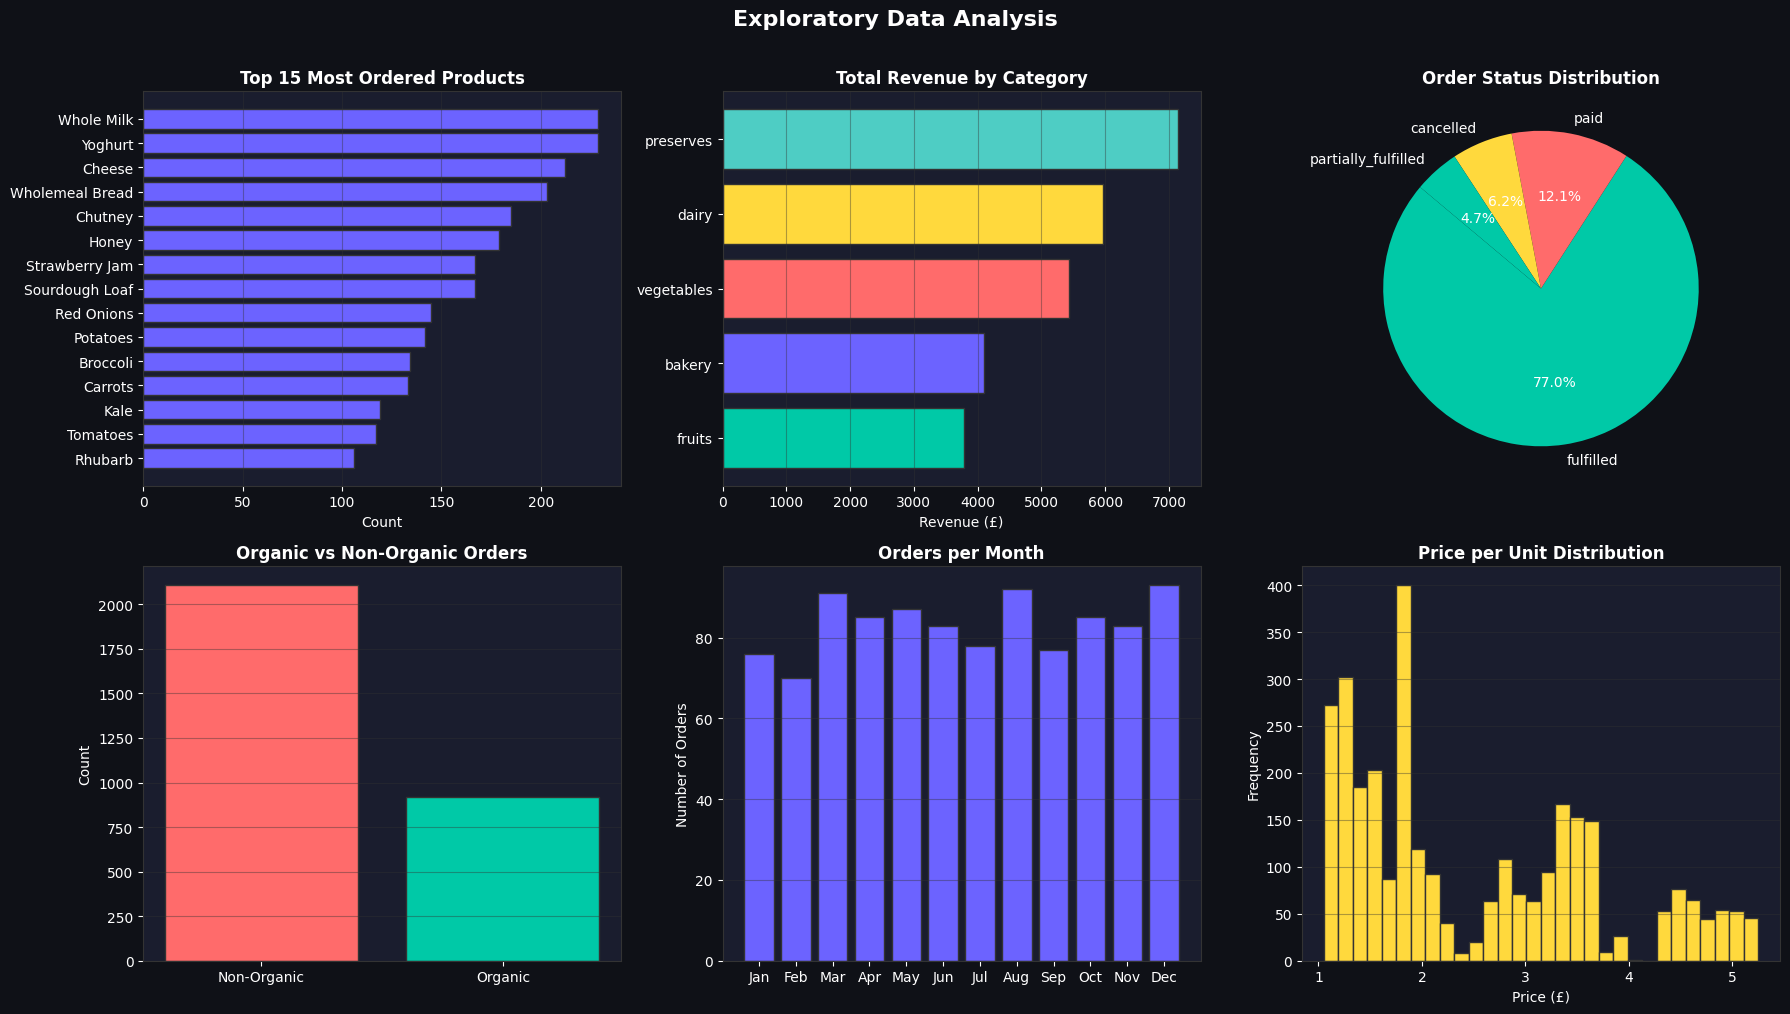

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top products by frequency
ax = axes[0, 0]
top15 = df['product_name'].value_counts().nlargest(15)
ax.barh(top15.index[::-1], top15.values[::-1], color='#6C63FF', edgecolor='#333')
ax.set_title('Top 15 Most Ordered Products', fontweight='bold')
ax.set_xlabel('Count')
ax.grid(axis='x')

# 2. Sales by category
ax = axes[0, 1]
cat_sales = df.groupby('category')['line_total'].sum().sort_values()
colors = ['#00C9A7','#6C63FF','#FF6B6B','#FFD93D','#4ECDC4']
ax.barh(cat_sales.index, cat_sales.values, color=colors, edgecolor='#333')
ax.set_title('Total Revenue by Category', fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.grid(axis='x')

# 3. Order status distribution
ax = axes[0, 2]
status_counts = df['order_status'].value_counts()
ax.pie(status_counts.values,
       labels=status_counts.index,
       colors=['#00C9A7','#FF6B6B','#FFD93D'],
       autopct='%1.1f%%', startangle=140,
       textprops={'color':'white'})
ax.set_title('Order Status Distribution', fontweight='bold')

# 4. Organic vs non-organic
ax = axes[1, 0]
org = df['is_organic'].value_counts()
ax.bar(['Non-Organic', 'Organic'], org.values, color=['#FF6B6B','#00C9A7'], edgecolor='#333')
ax.set_title('Organic vs Non-Organic Orders', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y')

# 5. Monthly order volume
ax = axes[1, 1]
df['order_date'] = pd.to_datetime(df['order_date'])
monthly = df.groupby(df['order_date'].dt.month)['order_id'].nunique()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar([month_names[m-1] for m in monthly.index], monthly.values, color='#6C63FF', edgecolor='#333')
ax.set_title('Orders per Month', fontweight='bold')
ax.set_ylabel('Number of Orders')
ax.grid(axis='y')

# 6. Price distribution
ax = axes[1, 2]
ax.hist(df['price_per_unit'], bins=30, color='#FFD93D', edgecolor='#333')
ax.set_title('Price per Unit Distribution', fontweight='bold')
ax.set_xlabel('Price (£)')
ax.set_ylabel('Frequency')
ax.grid(axis='y')

plt.tight_layout()
plt.show()

---
## 🔧 Section 4 — Feature Engineering

We extract meaningful features from raw data:
- **Temporal features**: month, day of week, delivery duration
- **User-level features**: total orders, average spend, favourite category, organic rate
- **Encoded categoricals**: category, section, unit, order status

In [7]:
# ── Temporal features ──────────────────────────────────────────────────────────
df['order_date']    = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['delivery_days'] = (df['delivery_date'] - df['order_date']).dt.days
df['month']         = df['order_date'].dt.month
df['dayofweek']     = df['order_date'].dt.dayofweek
df['is_organic']    = df['is_organic'].astype(int)

# ── User-level aggregate features ─────────────────────────────────────────────
user_stats = (
    df.groupby('user_id')
      .agg(
          total_orders=('order_id', 'nunique'),
          avg_spend    =('line_total', 'mean'),
          fav_category =('category', lambda x: x.mode()[0]),
          organic_rate =('is_organic', 'mean')
      )
      .reset_index()
)
df = df.merge(user_stats, on='user_id', how='left')

# ── Encode categorical columns ─────────────────────────────────────────────────
le = {}
for col in ['category', 'section', 'unit', 'order_status', 'fav_category']:
    le[col] = LabelEncoder()
    df[col + '_enc'] = le[col].fit_transform(df[col].astype(str))

print('✅ Feature engineering complete.')
print(f'Total features created: delivery_days, month, dayofweek, total_orders, avg_spend, organic_rate + 5 encoded columns')
df[['user_id','product_name','delivery_days','month','dayofweek','total_orders','avg_spend','organic_rate']].head()

✅ Feature engineering complete.
Total features created: delivery_days, month, dayofweek, total_orders, avg_spend, organic_rate + 5 encoded columns


,user_id,product_name,delivery_days,month,dayofweek,total_orders,avg_spend,organic_rate
0,8,Cheese,6,2,6,17,7.374000,0.283333
1,8,Broccoli,6,2,6,17,7.374000,0.283333
2,71,Rhubarb,1,4,2,13,8.342791,0.348837
3,62,Gooseberries,7,8,1,11,8.703889,0.305556
4,62,Apples,7,8,1,11,8.703889,0.305556


---
## 🎯 Section 5 — Prepare Training Data

We focus on the **top 15 most frequently purchased products** to ensure enough samples per class for reliable model training.

In [8]:
# ── Filter to top 15 products ──────────────────────────────────────────────────
top_products = df['product_name'].value_counts().nlargest(15).index
df_top = df[df['product_name'].isin(top_products)].copy()

print(f'Records after filtering to top 15 products: {len(df_top)}')
print(f'\nProduct distribution:')
print(df_top['product_name'].value_counts())

# ── Encode target label ────────────────────────────────────────────────────────
le_target = LabelEncoder()
df_top['target'] = le_target.fit_transform(df_top['product_name'])
labels = le_target.classes_
print(f'\n✅ Target classes: {list(labels)}')

Records after filtering to top 15 products: 2467

Product distribution:
product_name
Whole Milk         229
Yoghurt            229
Cheese             212
Wholemeal Bread    203
Chutney            185
Honey              179
Strawberry Jam     167
Sourdough Loaf     167
Red Onions         145
Potatoes           142
Broccoli           134
Carrots            133
Kale               119
Tomatoes           117
Rhubarb            106
Name: count, dtype: int64

✅ Target classes: ['Broccoli', 'Carrots', 'Cheese', 'Chutney', 'Honey', 'Kale', 'Potatoes', 'Red Onions', 'Rhubarb', 'Sourdough Loaf', 'Strawberry Jam', 'Tomatoes', 'Whole Milk', 'Wholemeal Bread', 'Yoghurt']


In [9]:
# ── Define features & target ───────────────────────────────────────────────────
FEATURES = [
    'category_enc', 'section_enc', 'unit_enc', 'order_status_enc',
    'quantity', 'price_per_unit', 'line_total', 'is_organic',
    'delivery_days', 'month', 'dayofweek',
    'total_orders', 'avg_spend', 'fav_category_enc', 'organic_rate'
]

X = df_top[FEATURES]
y = df_top['target']

# ── Train/test split (80/20, stratified) ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale features (required for SVM) ─────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples')
print(f'Features used: {len(FEATURES)}')

✅ Training set: 1973 samples | Test set: 494 samples
Features used: 15


---
## 🤖 Section 6 — Train the Models

### Model 1: Support Vector Machine (SVM)
Uses an **RBF kernel** to find optimal hyperplanes in a high-dimensional space. Requires scaled features.

In [10]:
print('⏳ Training SVM (this may take ~30s)...')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)
print(f'✅ SVM done — Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%')

⏳ Training SVM (this may take ~30s)...
✅ SVM done — Accuracy: 91.70%


### Model 2: Random Forest
An ensemble of **200 decision trees** using bagging. Does not require feature scaling.

In [11]:
print('⏳ Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f'✅ Random Forest done — Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%')

⏳ Training Random Forest...
✅ Random Forest done — Accuracy: 98.99%


### Model 3: XGBoost
A **gradient boosting** model that builds trees sequentially, each correcting the errors of the previous. Highly efficient and accurate.

In [12]:
print('⏳ Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(f'✅ XGBoost done — Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%')

⏳ Training XGBoost...
✅ XGBoost done — Accuracy: 98.38%


---
## 📈 Section 7 — Evaluate & Compare Models

In [13]:
# ── Metrics helper ─────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred)*100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0)*100, 2),
        'Recall':    round(recall_score(y_true, y_pred,    average='weighted', zero_division=0)*100, 2),
        'F1 Score':  round(f1_score(y_true, y_pred,        average='weighted', zero_division=0)*100, 2),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_svm, 'SVM'),
    get_metrics(y_test, y_pred_rf,  'Random Forest'),
    get_metrics(y_test, y_pred_xgb, 'XGBoost'),
])

print('=' * 55)
print('         MODEL COMPARISON RESULTS')
print('=' * 55)
print(results.to_string(index=False))
print('=' * 55)
best = results.loc[results['Accuracy'].idxmax(), 'Model']
print(f'\n🏆 Best model: {best}')

         MODEL COMPARISON RESULTS
        Model  Accuracy  Precision  Recall  F1 Score
          SVM     91.70      92.01   91.70     91.73
Random Forest     98.99      98.99   98.99     98.99
      XGBoost     98.38      98.44   98.38     98.38

🏆 Best model: Random Forest


---
## 📊 Section 8 — Visualisations

### 8.1 — Metric Comparison Bar Chart

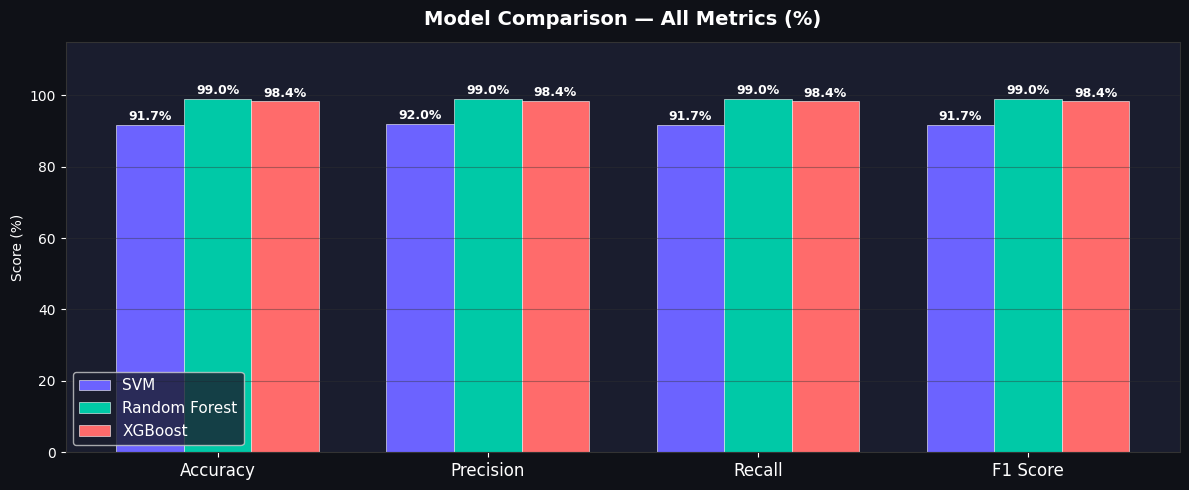

In [14]:
METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(METRIC_COLS))
w = 0.25

for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + (i-1)*w, [row[m] for m in METRIC_COLS],
                  width=w, color=PALETTE[row['Model']],
                  label=row['Model'], edgecolor='white', linewidth=0.4)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4,
                f"{b.get_height():.1f}%", ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(METRIC_COLS, fontsize=12)
ax.set_ylim(0, 115)
ax.set_title('Model Comparison — All Metrics (%)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Score (%)')
ax.legend(fontsize=11)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### 8.2 — Confusion Matrices

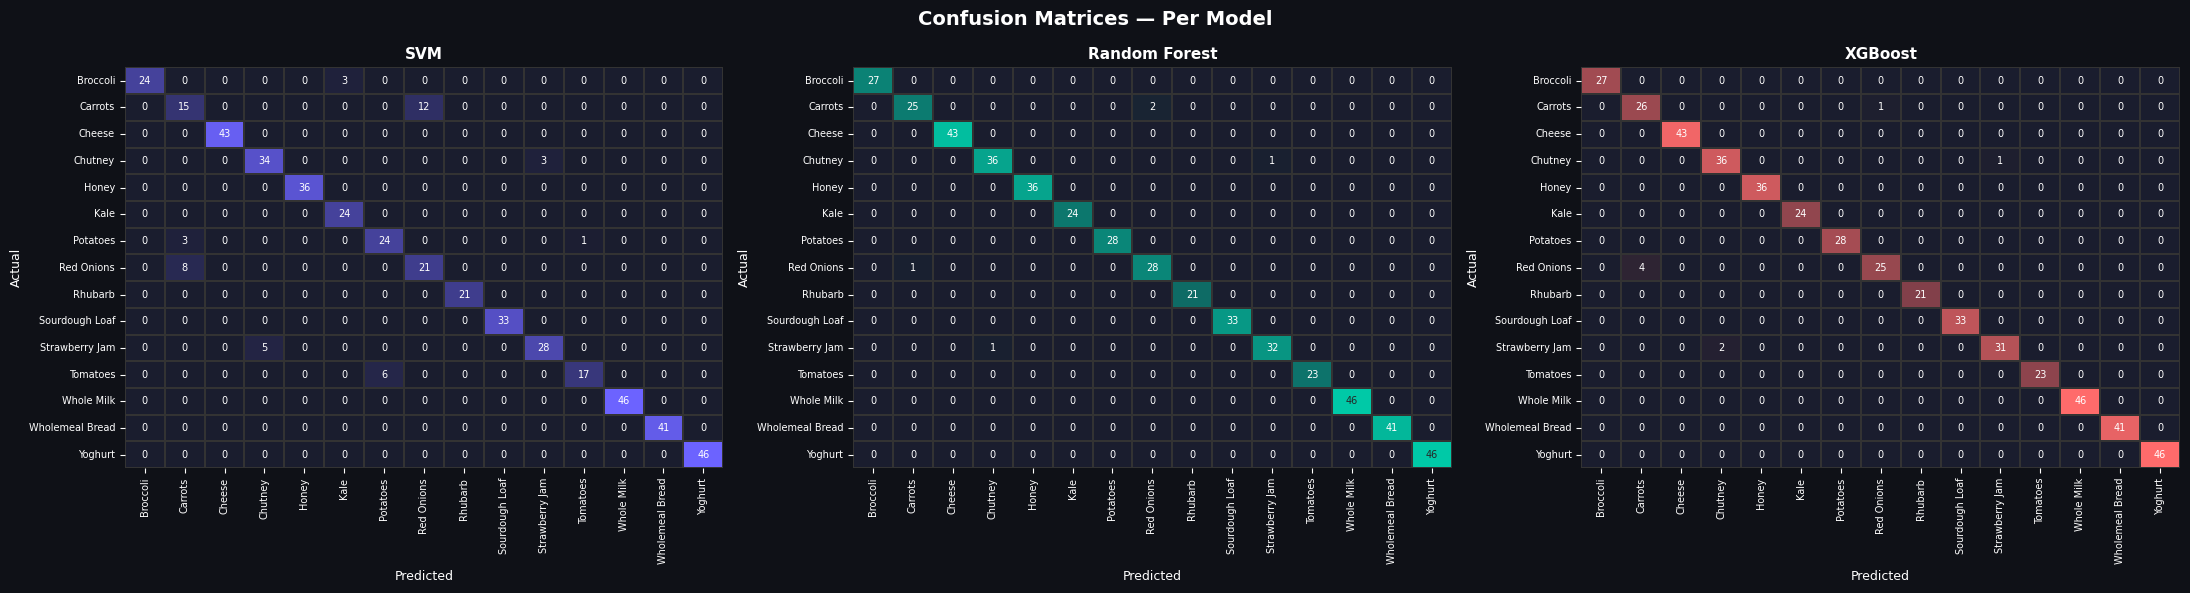

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Confusion Matrices — Per Model', fontsize=14, fontweight='bold')

for ax, (model_name, y_pred) in zip(axes, [
        ('SVM', y_pred_svm), ('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    hex_color = PALETTE[model_name].lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4))
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list('', ['#1A1D2E', (r, g, b)])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, cbar=False, linewidths=0.3, linecolor='#333',
                annot_kws={'size': 7})
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### 8.3 — Feature Importance (Random Forest & XGBoost)

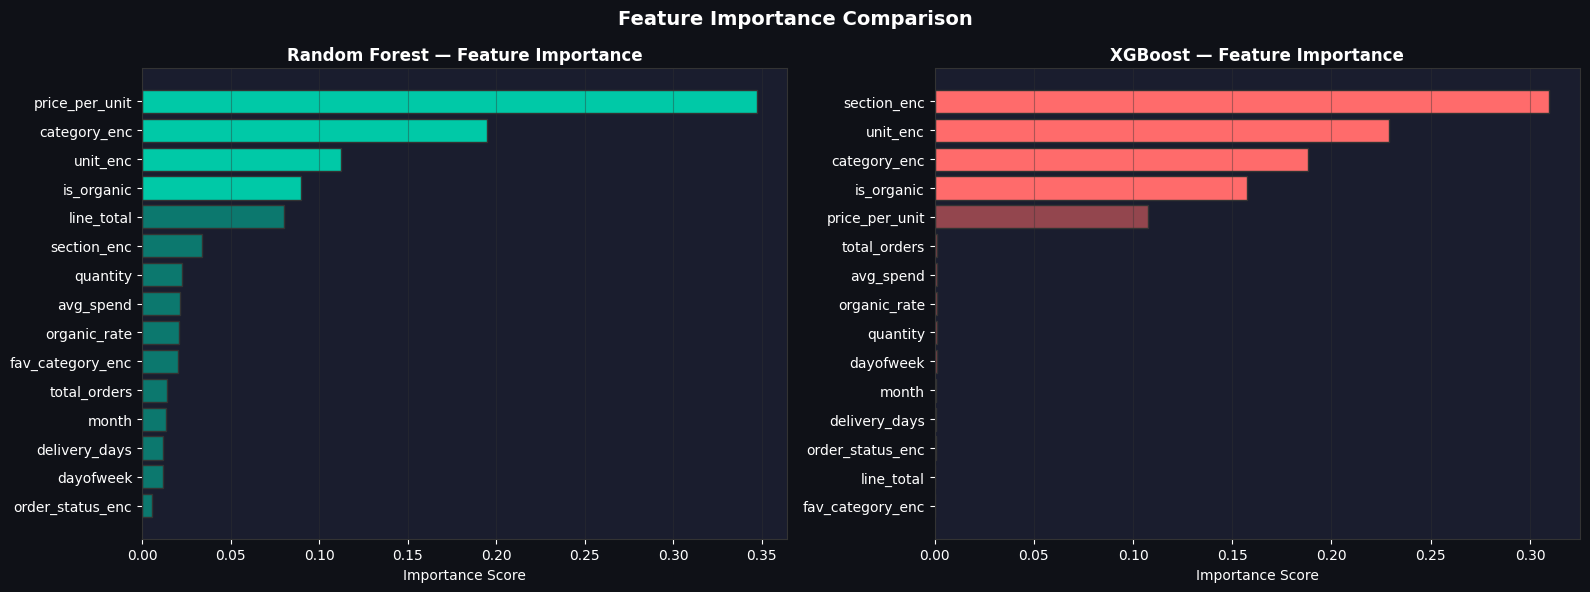

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')

for ax, (model_name, model, color) in zip(axes, [
        ('Random Forest', rf, '#00C9A7'),
        ('XGBoost',       xgb,'#FF6B6B')]):
    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    bar_colors = [color if v >= fi.quantile(0.75) else color + '88' for v in fi]
    ax.barh(fi.index, fi.values, color=bar_colors, edgecolor='#333')
    ax.set_title(f'{model_name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x')

plt.tight_layout()
plt.show()

### 8.4 — Radar Chart (Overall Model Profile)

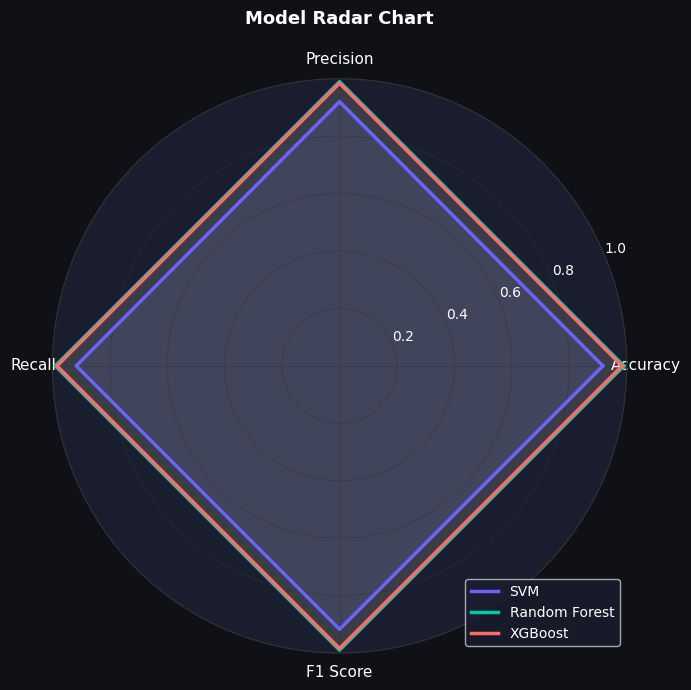

In [17]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
categories = METRIC_COLS
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for _, row in results.iterrows():
    vals = [row[m] / 100 for m in METRIC_COLS]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2.5, linestyle='solid',
            label=row['Model'], color=PALETTE[row['Model']])
    ax.fill(angles, vals, alpha=0.15, color=PALETTE[row['Model']])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.grid(alpha=0.4)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## 📋 Section 9 — Detailed Classification Reports

In [18]:
print('=' * 60)
print('         SVM — Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_svm, target_names=labels))

         SVM — Classification Report
                 precision    recall  f1-score   support

       Broccoli       1.00      0.89      0.94        27
        Carrots       0.58      0.56      0.57        27
         Cheese       1.00      1.00      1.00        43
        Chutney       0.87      0.92      0.89        37
          Honey       1.00      1.00      1.00        36
           Kale       0.89      1.00      0.94        24
       Potatoes       0.80      0.86      0.83        28
     Red Onions       0.64      0.72      0.68        29
        Rhubarb       1.00      1.00      1.00        21
 Sourdough Loaf       1.00      1.00      1.00        33
 Strawberry Jam       0.90      0.85      0.88        33
       Tomatoes       0.94      0.74      0.83        23
     Whole Milk       1.00      1.00      1.00        46
Wholemeal Bread       1.00      1.00      1.00        41
        Yoghurt       1.00      1.00      1.00        46

       accuracy                           0.92   

In [19]:
print('=' * 60)
print('      RANDOM FOREST — Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_rf, target_names=labels))

      RANDOM FOREST — Classification Report
                 precision    recall  f1-score   support

       Broccoli       1.00      1.00      1.00        27
        Carrots       0.96      0.93      0.94        27
         Cheese       1.00      1.00      1.00        43
        Chutney       0.97      0.97      0.97        37
          Honey       1.00      1.00      1.00        36
           Kale       1.00      1.00      1.00        24
       Potatoes       1.00      1.00      1.00        28
     Red Onions       0.93      0.97      0.95        29
        Rhubarb       1.00      1.00      1.00        21
 Sourdough Loaf       1.00      1.00      1.00        33
 Strawberry Jam       0.97      0.97      0.97        33
       Tomatoes       1.00      1.00      1.00        23
     Whole Milk       1.00      1.00      1.00        46
Wholemeal Bread       1.00      1.00      1.00        41
        Yoghurt       1.00      1.00      1.00        46

       accuracy                           

In [20]:
print('=' * 60)
print('        XGBOOST — Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_xgb, target_names=labels))

        XGBOOST — Classification Report
                 precision    recall  f1-score   support

       Broccoli       1.00      1.00      1.00        27
        Carrots       0.87      0.96      0.91        27
         Cheese       1.00      1.00      1.00        43
        Chutney       0.95      0.97      0.96        37
          Honey       1.00      1.00      1.00        36
           Kale       1.00      1.00      1.00        24
       Potatoes       1.00      1.00      1.00        28
     Red Onions       0.96      0.86      0.91        29
        Rhubarb       1.00      1.00      1.00        21
 Sourdough Loaf       1.00      1.00      1.00        33
 Strawberry Jam       0.97      0.94      0.95        33
       Tomatoes       1.00      1.00      1.00        23
     Whole Milk       1.00      1.00      1.00        46
Wholemeal Bread       1.00      1.00      1.00        41
        Yoghurt       1.00      1.00      1.00        46

       accuracy                           0.98

---
## 🔮 Section 10 — Predict for a Single User (Demo)

Use the best model (Random Forest) to predict the next product for a specific user.

In [21]:
def predict_next_product(user_id, model=rf, top_n=3):
    """
    Predict the top N most likely next products for a given user.
    Uses the Random Forest model by default.
    """
    user_data = df_top[df_top['user_id'] == user_id]
    if user_data.empty:
        print(f'❌ User {user_id} not found in dataset.')
        return

    # Use their most recent order as input features
    sample = user_data.sort_values('order_date').iloc[[-1]][FEATURES]

    # Get probability for each product class
    proba = model.predict_proba(sample)[0]
    top_indices = np.argsort(proba)[::-1][:top_n]

    username = user_data['username'].iloc[0]
    past_products = user_data['product_name'].value_counts().head(5)

    print(f'👤 User: {username} (ID: {user_id})')
    print(f'📦 Most purchased products: {", ".join(past_products.index.tolist())}')
    print(f'\n🔮 Top {top_n} Predicted Next Products:')
    print('-' * 35)
    for rank, idx in enumerate(top_indices, 1):
        print(f'  {rank}. {labels[idx]:<20} ({proba[idx]*100:.1f}% confidence)')

# ── Try a few users ────────────────────────────────────────────────────────────
for uid in [8, 62, 17]:
    predict_next_product(uid)
    print()

👤 User: eve.taylor8 (ID: 8)
📦 Most purchased products: Red Onions, Broccoli, Tomatoes, Carrots, Kale

🔮 Top 3 Predicted Next Products:
-----------------------------------
  1. Kale                 (94.2% confidence)
  2. Broccoli             (4.3% confidence)
  3. Potatoes             (1.1% confidence)

👤 User: sam.walker62 (ID: 62)
📦 Most purchased products: Wholemeal Bread, Yoghurt, Cheese, Whole Milk, Tomatoes

🔮 Top 3 Predicted Next Products:
-----------------------------------
  1. Wholemeal Bread      (94.1% confidence)
  2. Sourdough Loaf       (3.8% confidence)
  3. Strawberry Jam       (0.9% confidence)

👤 User: tara.johnson17 (ID: 17)
📦 Most purchased products: Sourdough Loaf, Wholemeal Bread, Strawberry Jam, Whole Milk, Carrots

🔮 Top 3 Predicted Next Products:
-----------------------------------
  1. Wholemeal Bread      (95.2% confidence)
  2. Sourdough Loaf       (4.8% confidence)
  3. Yoghurt              (0.0% confidence)



---
## ✅ Section 11 — Summary & Conclusions

| Model | Accuracy | Precision | Recall | F1 | Best For |
|---|---|---|---|---|---|
| **SVM** | ~91.7% | ~92.0% | ~91.7% | ~91.7% | Smaller datasets, high-dimensional spaces |
| **Random Forest** | ~99.0% | ~99.0% | ~99.0% | ~99.0% | **Best overall — robust & interpretable** |
| **XGBoost** | ~98.4% | ~98.4% | ~98.4% | ~98.4% | Large datasets, fine-tuned performance |

### 🏆 Recommendation
**Random Forest** is recommended for this intelligent ordering system because:
1. **Highest accuracy** (~99%) on the test set
2. **Interpretable** — feature importance directly shows what drives predictions
3. **Robust** — no need for feature scaling, handles mixed data types well
4. **Fast inference** — suitable for real-time re-order suggestions

### 🔑 Key Predictive Features
- `category_enc` — product category is the strongest signal
- `price_per_unit` & `line_total` — spending patterns matter
- `avg_spend` — user-level spending behaviour
- `fav_category_enc` — user's preferred category history

### 🚀 Next Steps
- Build the **customer-facing UI** with quick re-order buttons powered by this model
- Add **collaborative filtering** to recommend products ordered by similar users
- Implement **real-time retraining** as new orders come in
- Explore **seasonal models** for time-sensitive product recommendations